In [1]:
!pip show tensorflow numpy matplotlib seaborn scikit-learn kagglehub -q

# Uncomment to install if needed
# !pip install tensorflow numpy matplotlib seaborn scikit-learn kagglehub --quiet


In [2]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to  : {SEED}')


TensorFlow version : 2.20.0
Random seed set to  : 42


In [3]:
results_dir = "results/co17_lab8/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)
print("Results will be saved to:", results_dir)


Results will be saved to: results/co17_lab8/


In [4]:
!nvidia-smi

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(' -', gpu)
else:
    print('\nNo GPU found — training will run on CPU (slower). In Colab: Runtime > Change runtime type > T4 GPU.')


Fri Jul 31 12:21:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import kagglehub

kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [7]:
dataset_path = kagglehub.dataset_download("emmarex/plantdisease")
print("Dataset downloaded to:", dataset_path)


Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset downloaded to: /kaggle/input/plantdisease


In [8]:
def find_dataset_root(base_dir):
    """Walk the downloaded dataset to find the folder that contains the per-class subfolders."""
    for dirpath, dirnames, filenames in os.walk(base_dir):
        if any('tomato' in d.lower() for d in dirnames):
            return dirpath
    return None

dataset_root = find_dataset_root(dataset_path)
print("Dataset root:", dataset_root)

print("\nAll classes found:")
for d in sorted(os.listdir(dataset_root)):
    print(" -", d)


Dataset root: /kaggle/input/plantdisease/PlantVillage

All classes found:
 - Pepper__bell___Bacterial_spot
 - Pepper__bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Tomato_Bacterial_spot
 - Tomato_Early_blight
 - Tomato_Late_blight
 - Tomato_Leaf_Mold
 - Tomato_Septoria_leaf_spot
 - Tomato_Spider_mites_Two_spotted_spider_mite
 - Tomato__Target_Spot
 - Tomato__Tomato_YellowLeaf__Curl_Virus
 - Tomato__Tomato_mosaic_virus
 - Tomato_healthy


In [9]:
TARGET_CLASSES = ["Tomato_healthy", "Tomato_Early_blight"]
SPLIT_RATIOS = {"train": 0.80, "val": 0.10, "test": 0.10}
OUTPUT_ROOT = Path("/content/tomato_dataset")

if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

for split in SPLIT_RATIOS:
    for cls in TARGET_CLASSES:
        (OUTPUT_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

for cls in TARGET_CLASSES:
    src_folder = os.path.join(dataset_root, cls)
    images = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.Random(SEED).shuffle(images)

    n = len(images)
    n_train = int(n * SPLIT_RATIOS["train"])
    n_val = int(n * SPLIT_RATIOS["val"])

    split_files = {
        "train": images[:n_train],
        "val": images[n_train:n_train + n_val],
        "test": images[n_train + n_val:],
    }

    for split, files in split_files.items():
        for fname in files:
            shutil.copy(os.path.join(src_folder, fname), OUTPUT_ROOT / split / cls / fname)

    print(f"{cls}: total={n} -> train={len(split_files['train'])}, "
          f"val={len(split_files['val'])}, test={len(split_files['test'])}")

BASE_DIR = OUTPUT_ROOT
train_dir = BASE_DIR / "train"
val_dir = BASE_DIR / "val"
test_dir = BASE_DIR / "test"


Tomato_healthy: total=1591 -> train=1272, val=159, test=160
Tomato_Early_blight: total=1000 -> train=800, val=100, test=100


In [10]:
for split, d in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    exists = d.exists()
    count = sum(1 for _ in d.rglob('*.jpg')) + sum(1 for _ in d.rglob('*.JPG')) if exists else 0
    print(f'{split:>5} dir exists={exists} images≈{count}')


train dir exists=True images≈2072
  val dir exists=True images≈259
 test dir exists=True images≈260


In [11]:
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 64
EPOCHS = 50  # EarlyStopping will stop earlier once converged
LR = 1e-3    # Initial learning rate for the CNN trained from scratch

print(f'Image size   : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size   : {BATCH_SIZE}')
print(f'Max epochs   : {EPOCHS}')
print(f'Learning rate: {LR}')


Image size   : 128 x 128
Batch size   : 64
Max epochs   : 50
Learning rate: 0.001


In [12]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)


Found 2072 files belonging to 2 classes.
Found 259 files belonging to 2 classes.
Found 260 files belonging to 2 classes.


In [13]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')


Classes (2): ['Tomato_Early_blight', 'Tomato_healthy']


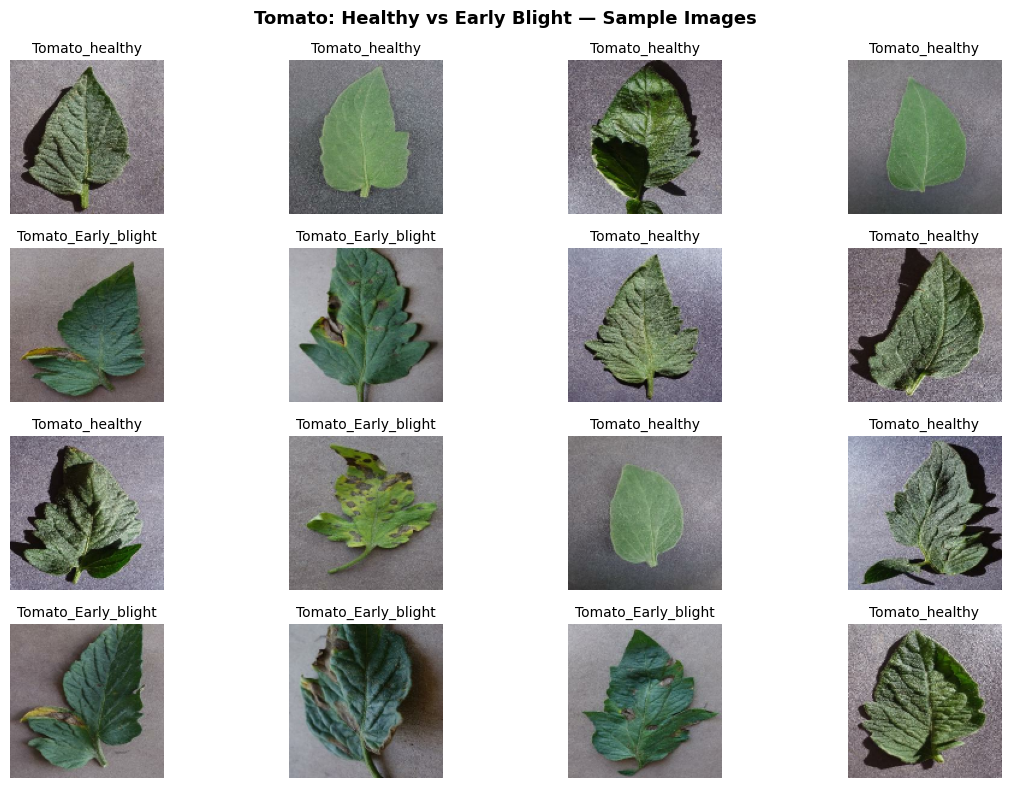

In [14]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')

plt.suptitle('Tomato: Healthy vs Early Blight — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'co17_samples.png', dpi=120, bbox_inches='tight')
plt.show()


In [15]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print('Pipeline optimised with cache + shuffle + prefetch.')


Pipeline optimised with cache + shuffle + prefetch.


In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')


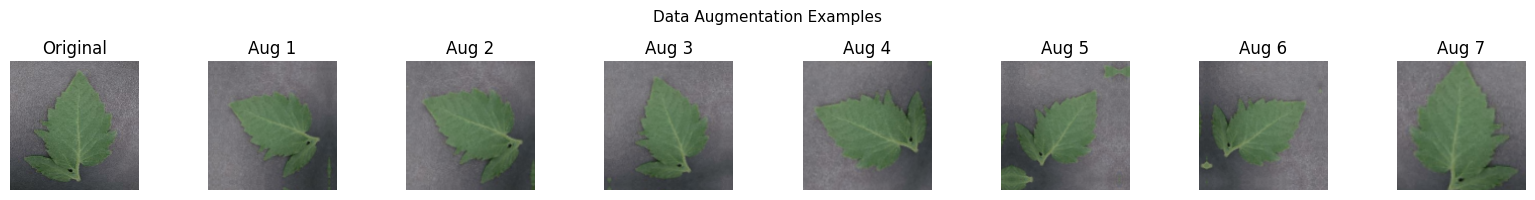

In [17]:
for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(results_dir + 'co17_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()


In [18]:
os.makedirs('models', exist_ok=True)

def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]


def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend(); plt.title(f'{title} — Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(results_dir + f'co17_{title.lower().replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()


def evaluate_model(model, dataset, class_names, title='Model'):
    """Evaluate a classification model and print/plot standard metrics."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(results_dir + f'co17_{title.lower().replace(" ", "_")}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')


Callbacks and utility functions defined.


In [19]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
OUTPUTS = num_classes

def build_custom_cnn(input_shape, augmentation):
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Classification head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name='custom_cnn')

cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [20]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)


In [22]:
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn'),
    verbose=1,
)


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 227ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9112 - val_loss: 0.2126 - learning_rate: 9.0000e-05
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step - accuracy: 1.0000 - loss: 9.0771e-04 - val_accuracy: 0.9151 - val_loss: 0.2664 - learning_rate: 9.0000e-05
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 228ms/step - accuracy: 1.0000 - loss: 9.9508e-04 - val_accuracy: 0.9266 - val_loss: 0.2565 - learning_rate: 9.0000e-05
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 229ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9344 - val_loss: 0.2207 - learning_rate: 9.0000e-05
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 1.0000 - loss: 9.0472e-04
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 233ms/step - accuracy: 1.0000 - loss: 9.6711e-04 - val_accuracy: 0.9266 - val_loss: 0.2329 - learning_rate: 9.0000e-05
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step -

In [23]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'Custom CNN -> val_accuracy: {cnn_val_acc:.4f}')


Custom CNN -> val_loss: 0.1127
Custom CNN -> val_accuracy: 0.9768


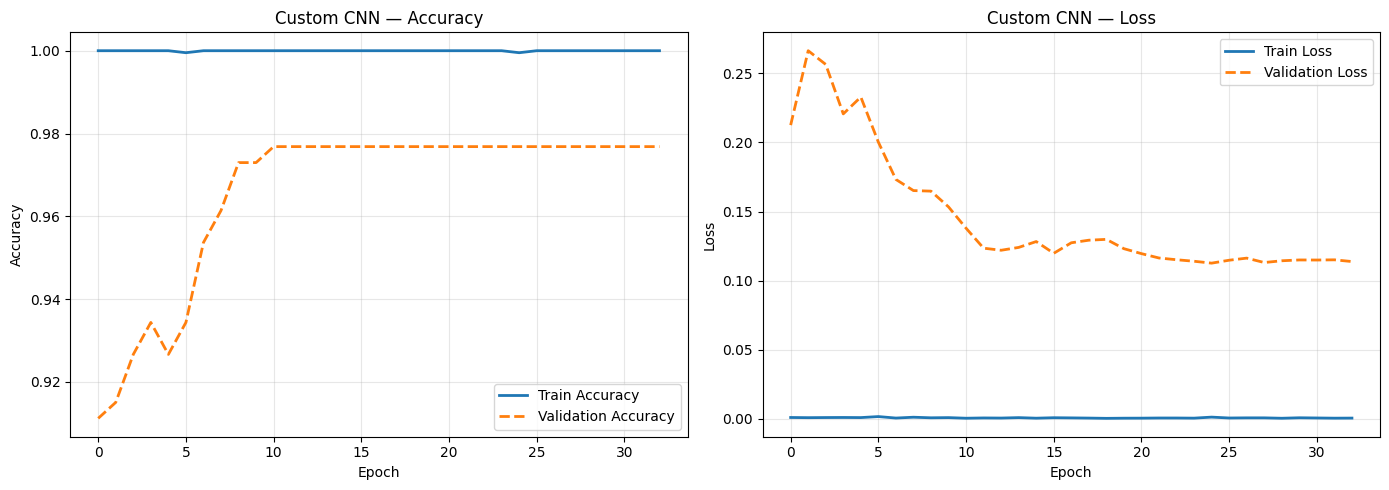

In [24]:
plot_learning_curves(cnn_history, 'Custom CNN')



Custom CNN
Accuracy  : 0.9731
Precision : 0.9742
Recall    : 0.9731
F1-Score  : 0.9729

Classification Report:
                     precision    recall  f1-score   support

Tomato_Early_blight     1.0000    0.9300    0.9637       100
     Tomato_healthy     0.9581    1.0000    0.9786       160

           accuracy                         0.9731       260
          macro avg     0.9790    0.9650    0.9712       260
       weighted avg     0.9742    0.9731    0.9729       260



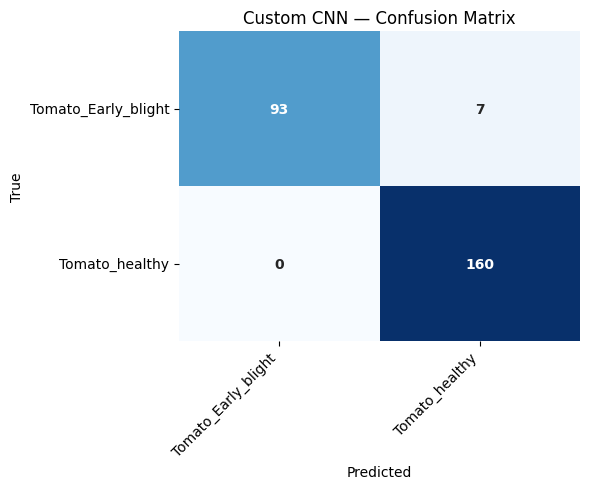

In [25]:
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')


In [26]:
def build_transfer_model(input_shape, augmentation, backbone='mobilenetv2'):
    if backbone == 'mobilenetv3small':
        base = tf.keras.applications.MobileNetV3Small(
            weights='imagenet', input_shape=input_shape, include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name = 'mobilenetv3small_transfer'
    else:
        base = tf.keras.applications.MobileNetV2(
            weights='imagenet', input_shape=input_shape, include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name = 'mobilenetv2_transfer'

    base.trainable = False  # Freeze all base layers for feature extraction
    print(f'Base model      : {base.name}')
    print(f'Trainable layers: {sum(1 for l in base.layers if l.trainable)} / {len(base.layers)}')

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name=model_name), base

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation, backbone='mobilenetv2')
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model      : mobilenetv2_1.00_128
Trainable layers: 0 / 154


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,434 (9.87 MB)

 Trainable params: 328,450 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
TL_LR = 1e-4

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.7954 - loss: 0.4276 - val_accuracy: 0.8919 - val_loss: 0.2825 - learning_rate: 1.0000e-04
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9402 - loss: 0.1710 - val_accuracy: 0.9421 - val_loss: 0.1822 - learning_rate: 1.0000e-04
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9628 - loss: 0.1217 - val_accuracy: 0.9537 - val_loss: 0.1365 - learning_rate: 1.0000e-04
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9566 - loss: 0.1193 - val_accuracy: 0.9691 - val_loss: 0.1092 - learning_rate: 1.0000e-04
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9681 - loss: 0.0975 - val_accuracy: 0.9730 - val_loss: 0.0976 - learning_rate: 1.0000e-04
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9730 - loss: 0.0765 - val_accuracy: 0.9653 - val_loss: 0.1023 - learning_rate: 1.0000e-04
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.976

MobileNetV2 TL -> val_loss: 0.0734
MobileNetV2 TL -> val_accuracy: 0.9807


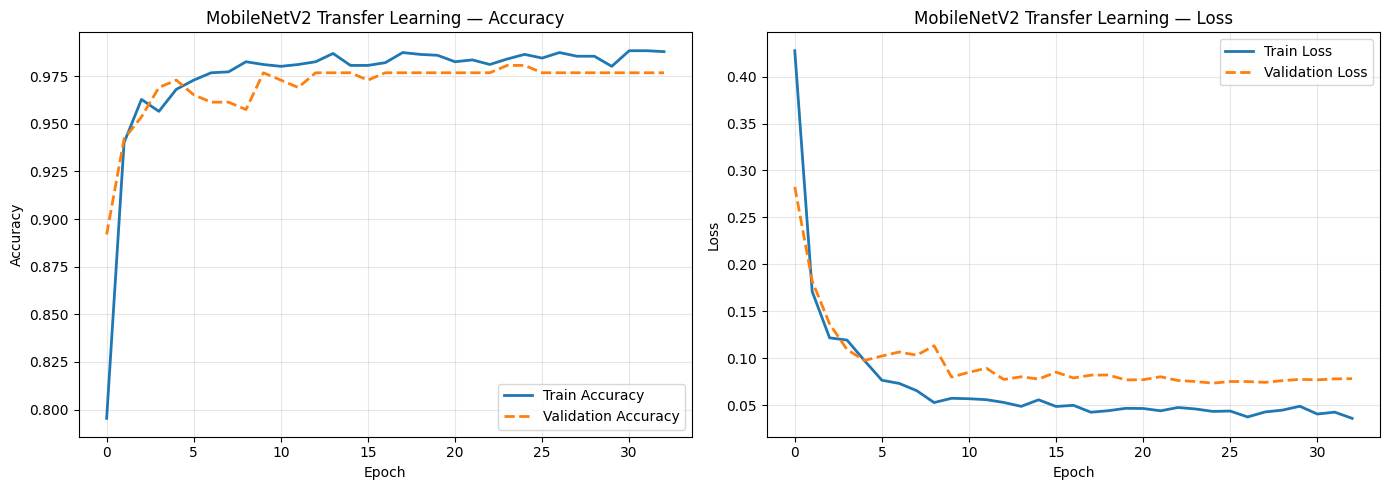

In [28]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV2 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV2 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV2 Transfer Learning')



MobileNetV2 Transfer
Accuracy  : 0.9846
Precision : 0.9850
Recall    : 0.9846
F1-Score  : 0.9846

Classification Report:
                     precision    recall  f1-score   support

Tomato_Early_blight     1.0000    0.9600    0.9796       100
     Tomato_healthy     0.9756    1.0000    0.9877       160

           accuracy                         0.9846       260
          macro avg     0.9878    0.9800    0.9836       260
       weighted avg     0.9850    0.9846    0.9846       260



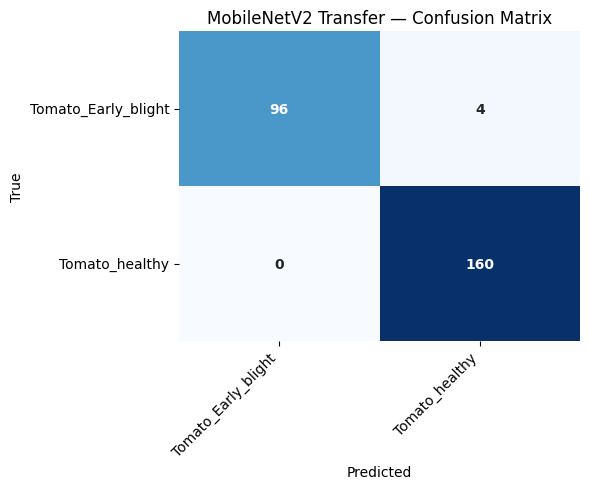

In [29]:
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV2 Transfer')


In [30]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')


Trainable base layers after unfreezing: 30 / 154


In [31]:
FINETUNE_LR = TL_LR / 10

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)


In [32]:
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=make_callbacks('tl_finetuned'),
    verbose=2,
)


Epoch 1/20
33/33 - 16s - 475ms/step - accuracy: 0.7978 - loss: 0.4461 - val_accuracy: 0.9189 - val_loss: 0.2111 - learning_rate: 1.0000e-05
Epoch 2/20
33/33 - 2s - 53ms/step - accuracy: 0.9503 - loss: 0.1335 - val_accuracy: 0.8996 - val_loss: 0.3080 - learning_rate: 1.0000e-05
Epoch 3/20
33/33 - 2s - 66ms/step - accuracy: 0.9667 - loss: 0.0912 - val_accuracy: 0.8996 - val_loss: 0.3171 - learning_rate: 1.0000e-05
Epoch 4/20
33/33 - 2s - 66ms/step - accuracy: 0.9739 - loss: 0.0692 - val_accuracy: 0.8996 - val_loss: 0.3213 - learning_rate: 1.0000e-05
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
33/33 - 2s - 52ms/step - accuracy: 0.9792 - loss: 0.0611 - val_accuracy: 0.9073 - val_loss: 0.3029 - learning_rate: 1.0000e-05
Epoch 6/20
33/33 - 2s - 52ms/step - accuracy: 0.9826 - loss: 0.0553 - val_accuracy: 0.9112 - val_loss: 0.2840 - learning_rate: 3.0000e-06
Epoch 7/20
33/33 - 2s - 52ms/step - accuracy: 0.9773 - loss: 0.0634 - val_accuracy: 0.9112 -

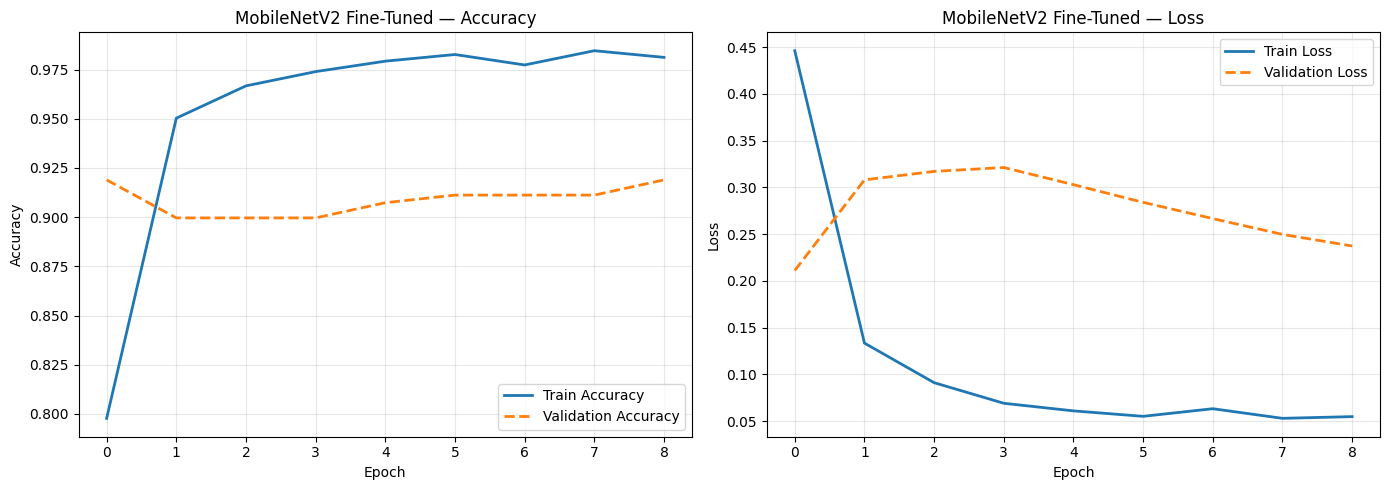

In [33]:
plot_learning_curves(ft_history, 'MobileNetV2 Fine-Tuned')



MobileNetV2 Fine-Tuned
Accuracy  : 0.9346
Precision : 0.9409
Recall    : 0.9346
F1-Score  : 0.9332

Classification Report:
                     precision    recall  f1-score   support

Tomato_Early_blight     1.0000    0.8300    0.9071       100
     Tomato_healthy     0.9040    1.0000    0.9496       160

           accuracy                         0.9346       260
          macro avg     0.9520    0.9150    0.9283       260
       weighted avg     0.9409    0.9346    0.9332       260



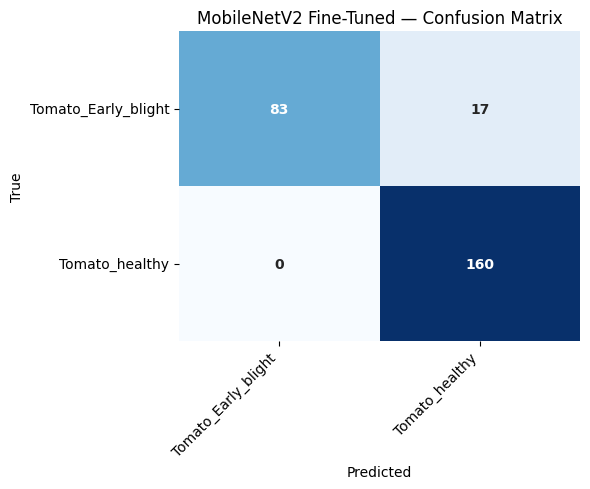

In [34]:
ft_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV2 Fine-Tuned')


In [35]:
results = {
    'Custom CNN': {'acc': cnn_test_acc, 'params': cnn_model.count_params()},
    'MobileNetV2 (TL)': {'acc': tl_test_acc, 'params': tl_model.count_params()},
    'MobileNetV2 (FT)': {'acc': ft_test_acc, 'params': tl_model.count_params()},
}

print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')


Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.9731        322,338
MobileNetV2 (TL)              0.9846      2,586,434
MobileNetV2 (FT)              0.9346      2,586,434


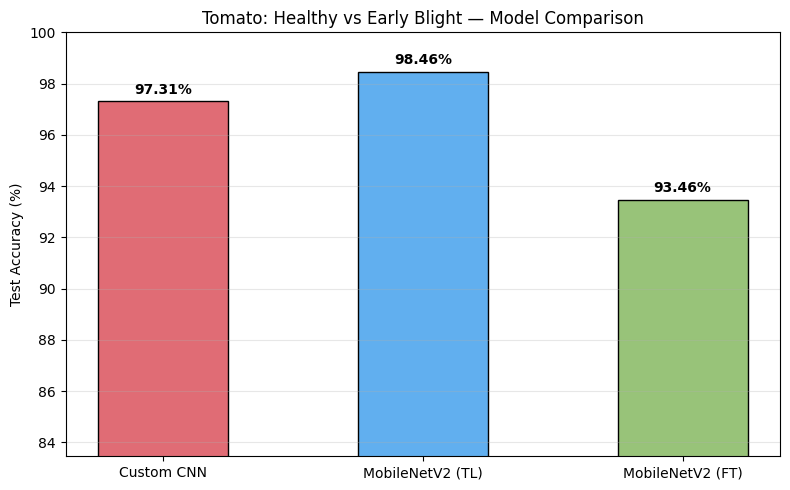

In [36]:
labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]
colors = ['#e06c75', '#61afef', '#98c379']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(min(accs) - 10 if min(accs) > 10 else 0, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Tomato: Healthy vs Early Blight — Model Comparison')
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(results_dir + 'co17_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [38]:
def predict_image(img_path, models_dict, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """Load an image file and classify it with each model in models_dict."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)          # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0)          # (1, H, W, 3)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        probs = mdl.predict(img_array, verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        label = class_names[pred_idx]
        print(f'{name:<25}: {label} (p={probs[pred_idx]:.4f})')


In [39]:
# predict_image(
#     'path/to/your/tomato_leaf.jpg',
#     {'Custom CNN': cnn_model, 'MobileNetV2 TL': tl_model},
#     class_names,
# )


In [40]:
os.makedirs('models', exist_ok=True)

cnn_model.save('models/co17_custom_cnn.keras')
tl_model.save('models/co17_mobilenetv2_finetuned.keras')

print('Models saved:')
print(' models/co17_custom_cnn.keras')
print(' models/co17_mobilenetv2_finetuned.keras')
print('Class order (must match app.py):', class_names)


Models saved:
 models/co17_custom_cnn.keras
 models/co17_mobilenetv2_finetuned.keras
Class order (must match app.py): ['Tomato_Early_blight', 'Tomato_healthy']


In [41]:
from google.colab import files

files.download('models/co17_custom_cnn.keras')
files.download('models/co17_mobilenetv2_finetuned.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>